# Análisis de series temporales
En el presente cuadernillo se hallan los modelos de análisis de series temporales, hecho en `R`, para el caso de análisis de este TFG. El análisis completo de los datos solo se realizará en este cuadernillo, mientras que en el cuadernillo <a href="Análisis temporal en Python.ipynb" target="_blank"><code>Análisis temporal en Python.ipynb</code></a> solo se replica el modelos y se realiza la comparación sintáctica para usarse como base para el uso del paquete `pyrcore` en la última parte del TFG.

**Caso de estudio**: Análisis temporal de las series de producción de gas de esquisto en varios sitios de EEUU para el periodo enero de 2000 a agosto de 2022 (2000.01-2022.08).

In [1]:
# Comprobar si se han instalado los siguientes paquetes:
# readxl
if (!require("readxl")){
    # En caso contrario, instalar y cargar
    install.packages("readxl")
    library(readxl)
}

# ggplot2
if (!require("ggplot2")){
    # En caso contrario, instalar y cargar
    install.packages("ggplot2")
    library(ggplot2)
}

# forecast
if (!require("forecast")){
    # En caso contrario, instalar y cargar
    install.packages("forecast")
    library(forecast)
}

Cargando paquete requerido: readxl

Cargando paquete requerido: ggplot2

Cargando paquete requerido: forecast



## Análisis de series temporales univariantes
Análisis temporal de las series de producción de gas de esquisto en varios sitios de EEUU para el periodo enero de 2000 a agosto de 2022 (2000.01-2022.08).

### Importación de datos
Extraer los datos necesarios del fichero Excel `data_shale_gas_010822.xlsx` en forma de serie temporal (`ts()`).

In [2]:
# Importar datos desde el fichero Excel
gas <- read_excel("..\\datasets\\data_shale_gas_010822.xlsx", range = "A2:J274")
# Estadísticos básicos
summary(gas)
# Previsualizar datos
head(gas)

      Date                      Barnett (TX)    Haynesville (LA & TX)
 Min.   :2000-01-01 00:00:00   Min.   :0.1337   Min.   : 0.07663     
 1st Qu.:2005-08-24 06:00:00   1st Qu.:1.2412   1st Qu.: 0.12348     
 Median :2011-04-16 00:00:00   Median :2.4836   Median : 3.72571     
 Mean   :2011-04-16 23:17:38   Mean   :2.6063   Mean   : 3.78632     
 3rd Qu.:2016-12-08 18:00:00   3rd Qu.:4.1608   3rd Qu.: 6.62490     
 Max.   :2022-08-01 00:00:00   Max.   :5.2176   Max.   :13.50900     
 Marcellus (PA, WV, OH & NY) Permian (TX & NM) Utica (OH, PA & WV)
 Min.   :3.238e-04           Min.   : 0.6047   Min.   :0.0001603  
 1st Qu.:9.216e-04           1st Qu.: 0.7047   1st Qu.:0.0005614  
 Median :3.048e+00           Median : 1.1195   Median :0.0015628  
 Mean   :8.408e+00           Mean   : 3.5309   Mean   :1.9919494  
 3rd Qu.:1.692e+01           3rd Qu.: 4.3446   3rd Qu.:4.2460048  
 Max.   :2.646e+01           Max.   :14.4236   Max.   :8.2354328  
 Woodford (OK)      Bakken (ND & MT)  Nio

Date,Barnett (TX),Haynesville (LA & TX),"Marcellus (PA, WV, OH & NY)",Permian (TX & NM),"Utica (OH, PA & WV)",Woodford (OK),Bakken (ND & MT),Niobrara-Codell (CO & WY),Mississippian (OK)
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2000-01-01,0.1337097,0.1410044,0.0008449676,0.6320696,0.0002948456,0.009290342,0.01350129,0.2571736,0.6870402
2000-02-01,0.1395305,0.1408326,0.0008446552,0.6423939,0.0002948455,0.008526182,0.01311571,0.2585000,0.6942075
2000-03-01,0.1505652,0.1402995,0.0008450582,0.6653018,0.0002948456,0.008625523,0.01286715,0.2585993,0.7042231
2000-04-01,0.1598422,0.1429651,0.0008437730,0.6800481,0.0002948454,0.008809750,0.01332514,0.2537982,0.6892704
2000-05-01,0.1639615,0.1436432,0.0008432027,0.7015090,0.0002948455,0.008715563,0.01284257,0.2530226,0.7242722
2000-06-01,0.1758135,0.1347880,0.0008413305,0.7060018,0.0002948454,0.008585956,0.01289556,0.2523684,0.7196170


Dado que se replica este trabajo de la asignatura *Data Modelling: Econometría*, se ha de elegir una de la series. En este caso, elegiré la primera serie temporal, del grupo *Barnett (TX)*.

In [3]:
# Extraer Barnett (TX) como serie temporal
gas <- ts( # Función "ts()" para creación de series temporales
    gas$`Barnett (TX)`, # Columna de "Barnett (TX)"
    start = 2000, # Comienza en enero del año 2000
    frequency = 12 # Datos mensuales
)
# Visualizar serie temporal
gas

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,0.1337097,0.1395305,0.1505652,0.1598422,0.1639615,0.1758135,0.1831470,0.1956057,0.2200013,0.2361483,0.2318962,0.2480042
2001,0.2487926,0.2547858,0.2551282,0.2813446,0.2956482,0.3042782,0.3016034,0.3411049,0.3552835,0.3657486,0.3885501,0.4137510
2002,0.4297093,0.4474885,0.4654373,0.4730318,0.5035106,0.5158035,0.5257212,0.5363703,0.5426804,0.5682318,0.5752675,0.5839523
2003,0.6105035,0.6246425,0.6504420,0.6590086,0.6769097,0.7038607,0.7368569,0.7436108,0.7737684,0.7901204,0.8104768,0.8231060
2004,0.8063770,0.8167529,0.8157459,0.8488610,0.8545382,0.8555280,0.8637915,0.8825335,0.9055426,0.9271694,0.9468529,0.9520694
2005,0.9687839,1.0166649,1.0518819,1.0713971,1.0848922,1.1340800,1.1747963,1.2359635,1.2429082,1.2775307,1.3650624,1.3919270
2006,1.4068482,1.4306189,1.4770999,1.5403447,1.6080382,1.6396713,1.6629551,1.7028087,1.7834204,1.8168647,1.8416311,1.9255228
2007,1.9816699,2.0543415,2.1828870,2.2721724,2.3994595,2.4887953,2.5963526,2.7862124,2.8524659,2.9584802,3.0931452,3.1874957
2008,3.3650468,3.4678798,3.5330519,3.5990130,3.7421895,3.7748708,3.8729944,4.0098303,4.0542047,4.2083240,4.2775916,4.3070970
2009,4.3428394,4.4397530,4.4632343,4.4196295,4.3370402,4.2762298,4.2284467,4.1585635,4.1007279,4.1252558,4.1103940,4.0911142


### Análisis clásico
Análisis clásico de series temporales univariantes.

#### Identificación del esquema
En primer lugar, se realiza un gráfico media-desviación típica para identificar si la serie sigue un esquema aditivo o multiplicativo.

In [4]:
# Hallar promedios y desviaciones típicas anuales
medias <- c(aggregate(gas, nfrequency = 1, FUN = mean))
desviaciones <- c(aggregate(gas, nfrequency = 1, FUN = sd))

# Unificar en un data.frame
media_desviacion <- data.frame(
    Media = medias, # Columna "Media"
    Desviación_típica = desviaciones, # Columna "Desviación_típica"
    row.names = 2000:2021 # Nombres de las filas (solo filas completas)
)
media_desviacion

,Media,Desviación_típica
,<dbl>,<dbl>
2000,0.1865188,0.03947625
2001,0.3171683,0.05508672
2002,0.5139337,0.05110342
2003,0.7169422,0.07330650
2004,0.8729802,0.05043848
2005,1.1679907,0.13641940
2006,1.6529853,0.16846009
2007,2.5711231,0.40669230
2008,3.8510078,0.32331293


In [5]:
# Ajustar tamaño de la ventana del dispositivo de gráficos
options(repr.plot.width = 10, repr.plot.height = 7.5)

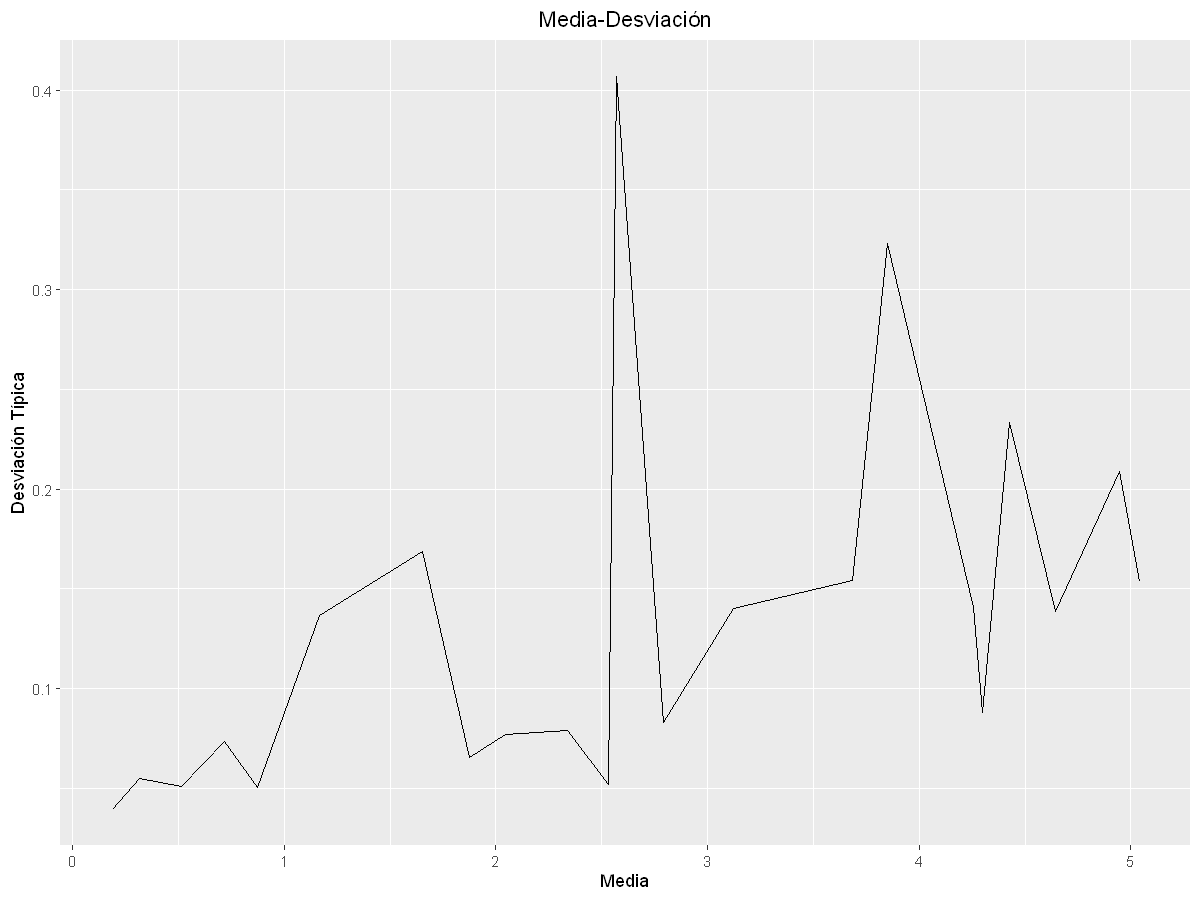

In [6]:
# Representar la media frente a la desviación típica anuales
ggplot(
    media_desviacion, # data.frame con promedios y desviaciones anuales
    aes(x = Media, y= Desviación_típica) # Ejes
) + geom_line() +
labs(
    title = "Media-Desviación",
    y = "Desviación Típica"
) +
theme(plot.title = element_text(hjust = 0.5))
ggsave("..\\Gráficos\\Media-Desviación.png", width = 10, height = 7.5)

Dado que la desviación típica varía a medida que lo hace la media, se concluye que la serie sigue un esquema **multiplicativo**.

#### Tendencia
Se representan gráficamente los datos para comprobar si existe una tendencia y, en tal caso, su forma.

pdf 
  2

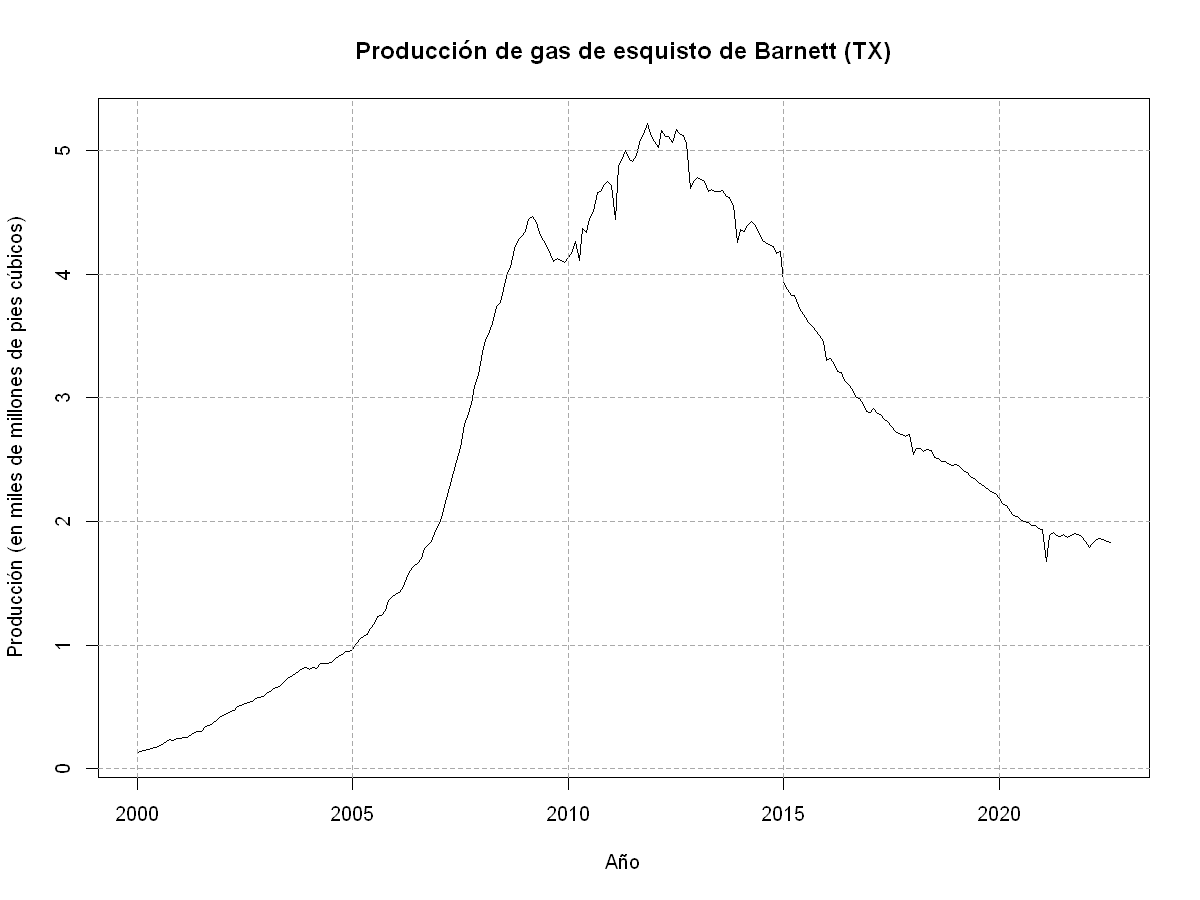

In [7]:
# Cambiar fondo a blanco
par(bg = "white")
# Generar gráfico
plot(
  gas, # Datos
  main = "Producción de gas de esquisto de Barnett (TX)", # Título
  xlab = "Año", # Etiqueta eje X
  ylab = "Producción (en miles de millones de pies cúbicos)" # Etiqueta eje Y
)
# Cuadrícula
grid(col = "darkgray", lty = "dashed")

# Almacenar gráfico
grafico <- recordPlot()

# Preparar ruta y tamaño para guardar el gráfico
png("..\\Gráficos\\Serie temporal.png", width = 1000, height = 750)

# Reproducir gráfico para guardarlo
replayPlot(grafico)

# Cerrar archivo .png
dev.off()

# Liberar espacio en memoria borrando la variable gráfico
rm(grafico)

Parece observarse una tendencia cuadrática.

#### Descomposición
Se procede a la descomposición en la tendencia y componente estacional.

In [8]:
# Descomponer serie temporal
descomposicion <- decompose(gas, type = "multiplicative")
# Obtener tendencia
tendencia <- descomposicion$trend
# Cálculo de Índices de Variación Estacional (IVEs)
ives <- tapply(descomposicion$seasonal, cycle(descomposicion$seasonal), mean)
# Mostrar tendencia e IVEs
tendencia
print(ives)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,NA,NA,NA,NA,NA,NA,0.1913139,0.2009113,0.2100704,0.2194898,0.2300394,0.2408790
2001,0.2511674,0.2621655,0.2738648,0.2849015,0.2968288,0.3102622,0.3247065,0.3402739,0.3570661,0.3738159,0.3904638,0.4079383
2002,0.4260901,0.4435644,0.4595087,0.4757537,0.4919704,0.5068420,0.5214668,0.5363813,0.5514712,0.5669288,0.5819028,0.5969635
2003,0.6135965,0.6310289,0.6492926,0.6681666,0.6872123,0.7069775,0.7251036,0.7412696,0.7561618,0.7709600,0.7862717,0.7999924
2004,0.8116008,0.8226782,0.8339572,0.8451582,0.8565509,0.8676067,0.8797471,0.8948438,0.9130124,0.9321238,0.9509942,0.9721986
2005,0.9967635,1.0244482,1.0532314,1.0818867,1.1139105,1.1496633,1.1862433,1.2217441,1.2567096,1.2939665,1.3353038,1.3781678
2006,1.4195741,1.4593659,1.5013391,1.5463327,1.5886620,1.6307522,1.6769362,1.7268756,1.7822718,1.8421724,1.9056411,1.9739972
2007,2.0482689,2.1323023,2.2219877,2.3140986,2.4138123,2.5185409,2.6287638,2.7453020,2.8604563,2.9719982,3.0832303,3.1927638
2008,3.2995437,3.4037212,3.5047777,3.6069270,3.7083558,3.8043578,3.8917492,3.9729853,4.0522376,4.1251875,4.1841653,4.2298407
2009,4.2655412,4.2865489,4.2946846,4.2931619,4.2827342,4.2667683,4.2490256,4.2289864,4.2094902,4.1885002,4.1769177,4.1805955


        1         2         3         4         5         6         7         8 
0.9936548 0.9859544 0.9985580 0.9988502 1.0037887 0.9992063 0.9955713 1.0013931 
        9        10        11        12 
1.0057898 1.0092793 1.0050949 1.0028593 


Los **Í**ndices de **V**ariación **E**stacional (**IVE**s) son extremadamente cercanos a 1, por lo que no hay componente estacional significativa.

Aquí concluye el análisis clásico y se da paso a la metodología *Box-Jenkins*.

### Metodología *Box-Jenkins*

#### Estudiar la estacionariedad de la serie

##### Media

En el análisis clásico pareció observarse una tendencia cuadrática. Se procede a la comprobación de la tendencia.

In [9]:
# Usando el vector "medias"
medias

[1] 0.1865188 0.3171683 0.5139337 0.7169422 0.8729802 1.1679907 1.6529853
 [8] 2.5711231 3.8510078 4.2577690 4.4284212 4.9448931 5.0404751 4.6435245
[15] 4.3005397 3.6866805 3.1225326 2.7892816 2.5296870 2.3388427 2.0433561
[22] 1.8759390

pdf 
  2

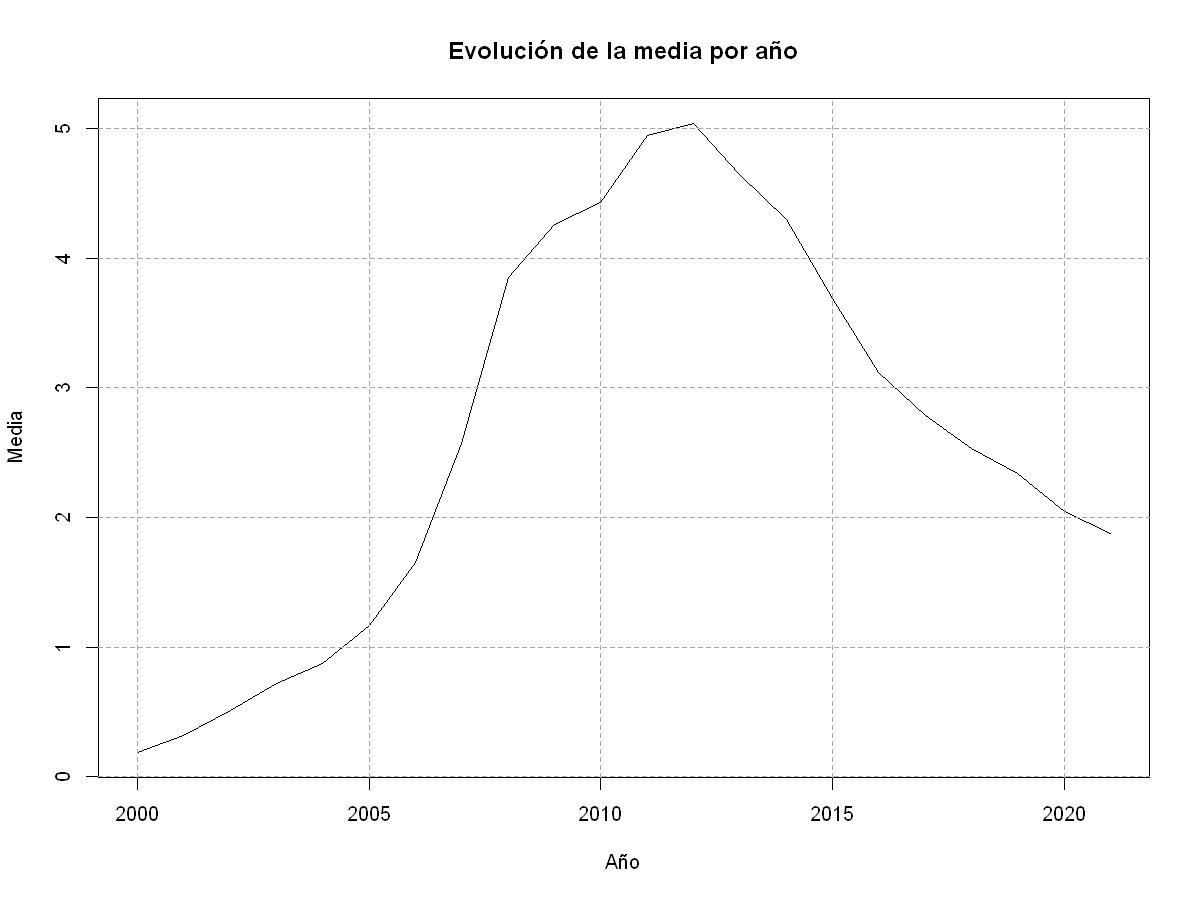

In [10]:
# Representar, mediante un diagrama de líneas, los promedios anuales
par(bg = "white")
plot(
  2000:2021, medias,
  type = "l",
  main = "Evolución de la media por año",
  xlab = "Año",
  ylab = "Media"
)
grid(col = "darkgray", lty = "dashed")
grafico <- recordPlot()
png("..\\Gráficos\\Media-Tiempo.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

En efecto, se observa una tendencia cuadrática.

La serie **no es estacionaria en media** y, como la tendencia es cuadrática, requerirá aplicar **dos diferencias lineales**.

##### Varianza

Representar gráficamente la evolución de la varianza respecto al tiempo para comprobar si es <ins>heterocedástica</ins> (no estacionaria en varianza) u <ins>homocedástica</ins> (estacionaria en varianza).

In [11]:
# Usando el vector desviaciones
desviaciones ^ 2

[1] 0.001558374 0.003034547 0.002611560 0.005373843 0.002544040 0.018610252
 [7] 0.028378802 0.165398630 0.104531253 0.019801008 0.054531028 0.043533540
[13] 0.023671828 0.019231565 0.007790061 0.023760987 0.019695938 0.006853511
[19] 0.002705725 0.006200985 0.005939894 0.004309057

pdf 
  2

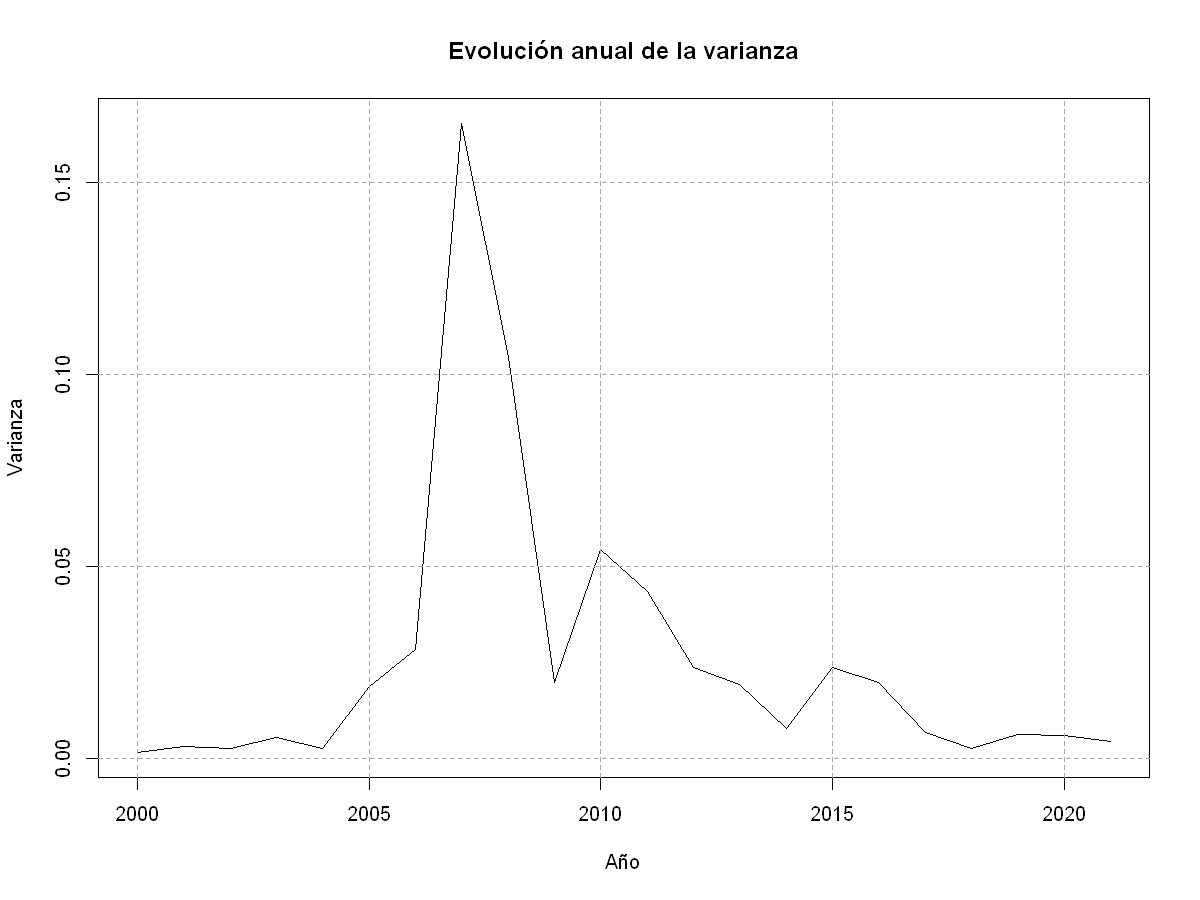

In [12]:
# Representar, mediante un diagrama de líneas, las varianzas anuales
par(bg = "white")
plot(
  2000:2021, desviaciones ^ 2,
  type = "l",
  main = "Evolución anual de la varianza",
  xlab = "Año",
  ylab = "Varianza"
)
grid(col = "darkgray", lty = "dashed")
grafico <- recordPlot()
png("..\\Gráficos\\Varianza-Tiempo.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

La varianza no es constante a lo largo del tiempo. Sin embargo, dado que no existe un patrón en las variaciones de la varianza, se considera que estas fluctuaciones se deben a elementos accidentales.

**<ins>NO</ins>** se requiere **transformación logarítmica**. El cálculo de $\lambda$ para estabilización de la varianza no ha sido aprendido durante el curso. Afortunadamente, existen funciones para integrar su uso en la modelización como, por ejemplo, la transformación de Box-Cox.

##### Componente estacional
Dado que no hay componente estacional significativa, no se requiren transformaciones estacionales.

#### Transformación de la serie

##### Separación

In [13]:
# Conjunto de entrenamiento
train <- window(gas, end = c(2022, 3))

# Conjunto de prueba
test <- window(gas, start = c(2022, 4))

# Visualizar
train
test

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,0.1337097,0.1395305,0.1505652,0.1598422,0.1639615,0.1758135,0.1831470,0.1956057,0.2200013,0.2361483,0.2318962,0.2480042
2001,0.2487926,0.2547858,0.2551282,0.2813446,0.2956482,0.3042782,0.3016034,0.3411049,0.3552835,0.3657486,0.3885501,0.4137510
2002,0.4297093,0.4474885,0.4654373,0.4730318,0.5035106,0.5158035,0.5257212,0.5363703,0.5426804,0.5682318,0.5752675,0.5839523
2003,0.6105035,0.6246425,0.6504420,0.6590086,0.6769097,0.7038607,0.7368569,0.7436108,0.7737684,0.7901204,0.8104768,0.8231060
2004,0.8063770,0.8167529,0.8157459,0.8488610,0.8545382,0.8555280,0.8637915,0.8825335,0.9055426,0.9271694,0.9468529,0.9520694
2005,0.9687839,1.0166649,1.0518819,1.0713971,1.0848922,1.1340800,1.1747963,1.2359635,1.2429082,1.2775307,1.3650624,1.3919270
2006,1.4068482,1.4306189,1.4770999,1.5403447,1.6080382,1.6396713,1.6629551,1.7028087,1.7834204,1.8168647,1.8416311,1.9255228
2007,1.9816699,2.0543415,2.1828870,2.2721724,2.3994595,2.4887953,2.5963526,2.7862124,2.8524659,2.9584802,3.0931452,3.1874957
2008,3.3650468,3.4678798,3.5330519,3.5990130,3.7421895,3.7748708,3.8729944,4.0098303,4.0542047,4.2083240,4.2775916,4.3070970
2009,4.3428394,4.4397530,4.4632343,4.4196295,4.3370402,4.2762298,4.2284467,4.1585635,4.1007279,4.1252558,4.1103940,4.0911142


,Apr,May,Jun,Jul,Aug
2022,1.851401,1.864867,1.853627,1.842455,1.831349


##### Diferencia lineal
Fórmula matemática:
$\Delta y_t = y_t - y_{t-1}$

$\Delta^d y_t = y_t - y_{t-1} - y_{t-2} - ... - y_{t-d}$

In [14]:
# DOS diferencias lineales
train <- diff(train, differences = 2)
train

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,,,0.0052139610,-0.0017576801,-0.0051577560,0.0077326313,-0.0045184365,0.0051252929,0.0119367703,-0.0082485142,-0.0203992268,0.0203602841
2001,-0.0153197308,0.0052048158,-0.0056507531,0.0258739567,-0.0119128275,-0.0056735670,-0.0113047151,0.0421761830,-0.0253228163,-0.0037135986,0.0123365110,0.0023993145
2002,-0.0092425838,0.0018209024,0.0001695885,-0.0103542523,0.0228842940,-0.0181859229,-0.0023752211,0.0007314616,-0.0043390901,0.0192413901,-0.0185157794,0.0016491677
2003,0.0178664304,-0.0124122846,0.0116605458,-0.0172329170,0.0093344675,0.0090499347,0.0060451783,-0.0262422567,0.0234037175,-0.0138056597,0.0040043685,-0.0077271011
2004,-0.0293582231,0.0271048015,-0.0113827929,0.0341220287,-0.0274377949,-0.0046875108,0.0072737424,0.0104785383,0.0042670036,-0.0013822316,-0.0019432559,-0.0144670481
2005,0.0114979460,0.0311665239,-0.0126639533,-0.0157017892,-0.0060201869,0.0356927578,-0.0084714532,0.0204508627,-0.0542225117,0.0276777325,0.0529093502,-0.0606671870
2006,-0.0119434848,0.0088496600,0.0227102317,0.0167637726,0.0044487597,-0.0360604842,-0.0083492823,0.0165698969,0.0407579864,-0.0471673212,-0.0086779680,0.0591253353
2007,-0.0277446047,0.0165244951,0.0558739301,-0.0392601295,0.0380017350,-0.0379512738,0.0182214140,0.0823024944,-0.1236062476,0.0397608479,0.0286505635,-0.0403143725
2008,0.0832004929,-0.0747179961,-0.0376610003,0.0007890654,0.0772154294,-0.1104952263,0.0654422964,0.0387122366,-0.0924614124,0.1097447895,-0.0848515463,-0.0397622849
2009,0.0062370126,0.0611711305,-0.0734322366,-0.0670860572,-0.0389845327,0.0217788137,0.0130274173,-0.0221001380,0.0120475633,0.0823635365,-0.0393896773,-0.0044180223


#### Identificación del modelo

##### Correlogramas

pdf 
  2

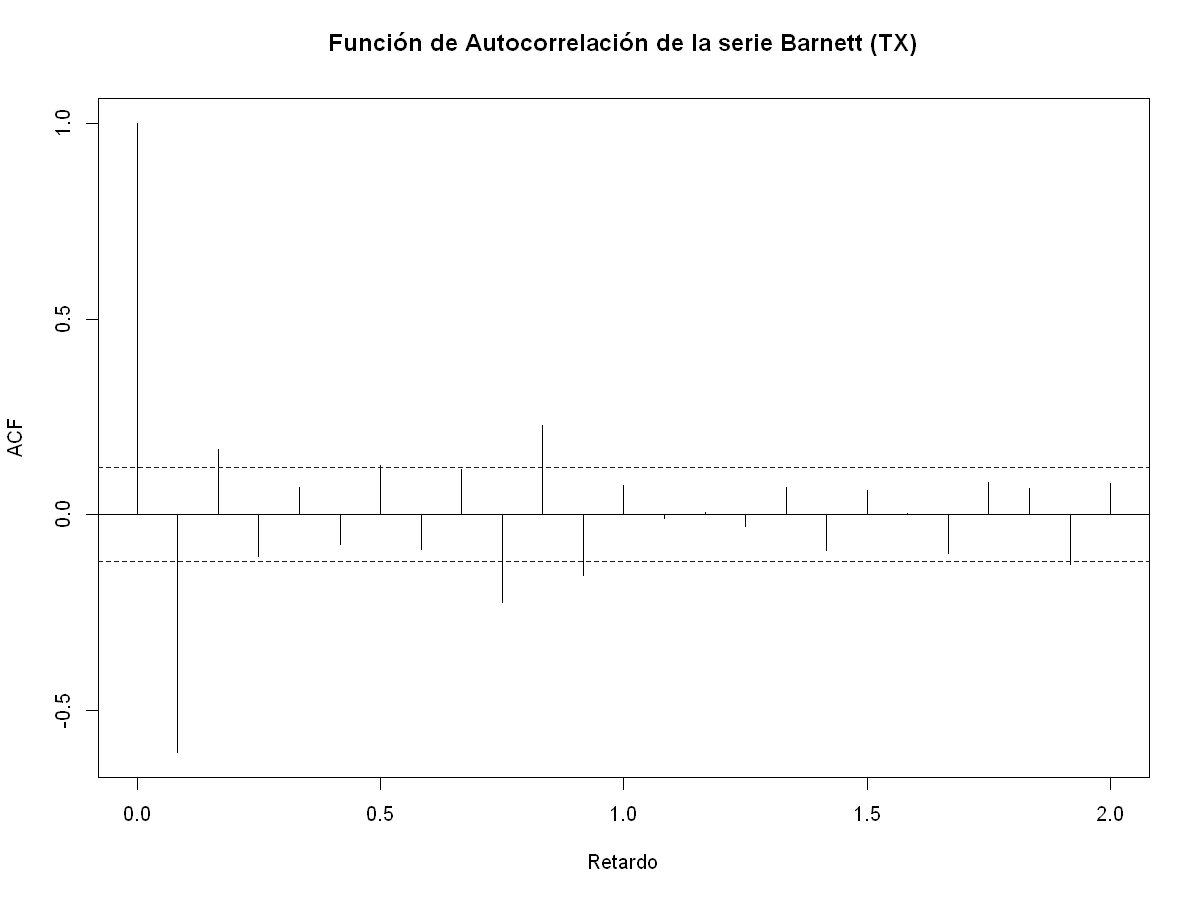

In [15]:
# Función de Autocorrelación
par(bg = "white")
acf(
    train,
    main = "Función de Autocorrelación de la serie Barnett (TX)",
    xlab = "Retardo"
)
grafico <- recordPlot()
png("..\\Gráficos\\ACF.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

pdf 
  2

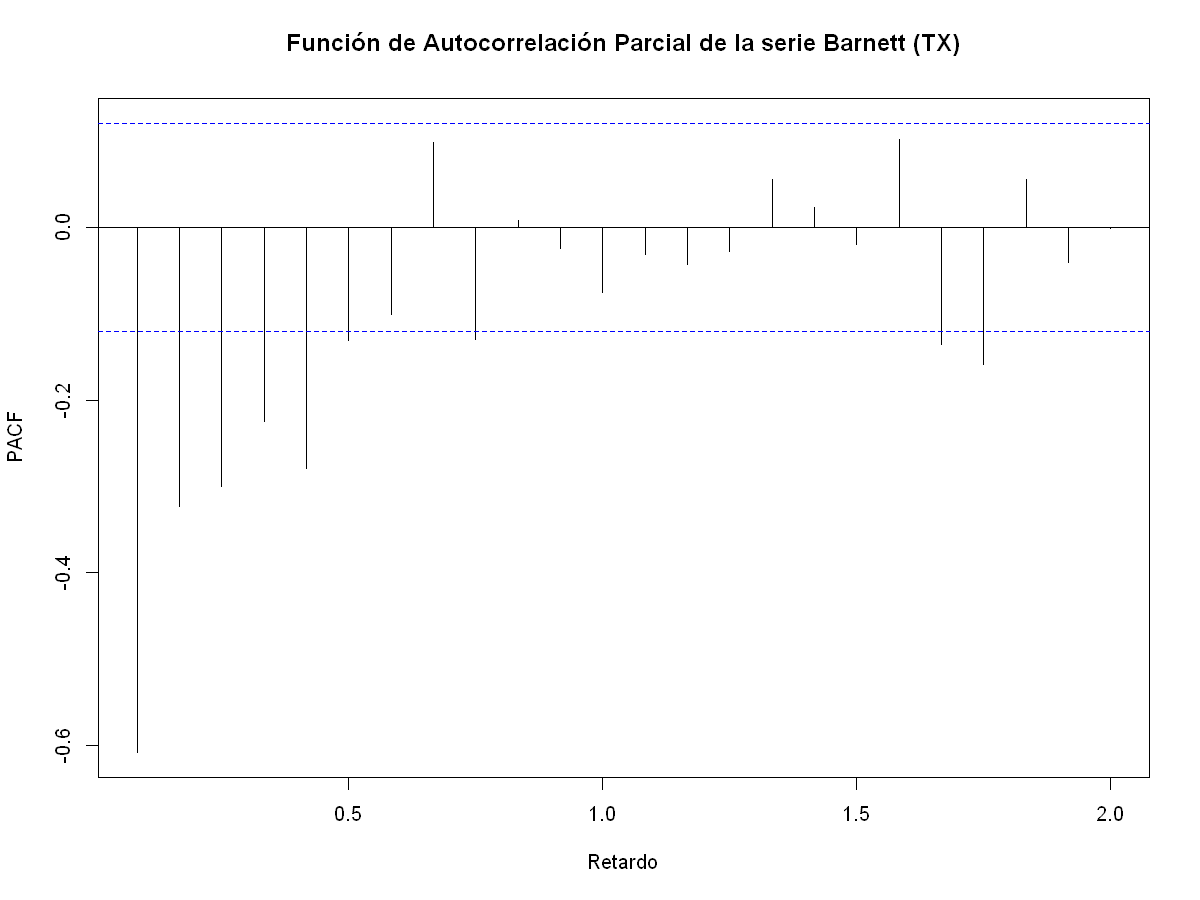

In [16]:
# Función de Autocorrelación Parcial
par(bg = "white")
pacf(
    train,
    main = "Función de Autocorrelación Parcial de la serie Barnett (TX)",
    xlab = "Retardo", ylab = "PACF"
)
grafico <- recordPlot()
png("..\\Gráficos\\PACF.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)

**MA(q=2)**: La ACF empieza en negativo, pasa ligeramente a positivo y se corta abruptamente a partir de ahí. La PACF presenta una forma de onda sinusoidal.

Por tanto, el modelo es un **MA(2)** (`q = 2`).

#### Estimación de los coeficientes de los modelos

Se ajusta un modelo ARIMA a la **serie transformada**.

In [17]:
# Modelo MA(2)
modelo <- arima(train, order = c(0, 0, 2))
modelo


Call:
arima(x = train, order = c(0, 0, 2))

Coefficients:
          ma1     ma2  intercept
      -1.0851  0.2159     -1e-04
s.e.   0.0620  0.0651      5e-04

sigma^2 estimated as 0.004416:  log likelihood = 341.61,  aic = -675.23

#### Contraste de validez del modelo
Evalúa el modelo utilizando métricas como AIC, RMSE, etc.

In [18]:
print(paste("AIC:", AIC(modelo)))
print(paste("BIC:", BIC(modelo)))

[1] "AIC: -675.226571366445"
[1] "BIC: -660.9076520625"


In [19]:
pred <- forecast(modelo, h = length(test))
accuracy(pred)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,4.69895e-05,0.06645511,0.03723281,97.85249,264.5068,0.4698908,-0.002455678


#### Análisis detallado de los errores

In [20]:
Box.test(
    residuals(modelo),
    lag = log(length(train)) * 10,
    type = "Ljung-Box",
    fitdf = 4
)


	Box-Ljung test

data:  residuals(modelo)
X-squared = 72.028, df = 51, p-value = 0.02783


p-valor < $\alpha$ => no es ruido blanco. Probablemente se deba a la ausencia de la transformación de Box-Cox. A continuación se hace una comprobación con `auto.arima()`.

In [21]:
# Comprobación
Box.test(
    residuals(
        auto.arima(
            window(gas, end = c(2022, 3)), # Conjunto de train sin transformar
            lambda = "auto" # Cálculo automático de lambda
        )
    ),
    lag = log(length(train)) * 10,
    type = "Ljung-Box",
    fitdf = 4
)


	Box-Ljung test

data:  residuals(auto.arima(window(gas, end = c(2022, 3)), lambda = "auto"))
X-squared = 45.605, df = 51, p-value = 0.6871


p-valor > $\alpha$ => no es ruido blanco.

Véase que `auto.arima()` establece que la serie temporal responde a un modelo `ARIMA(0, 2, 2)`.

In [22]:
auto.arima(window(gas, end = c(2022, 3)), lambda = "auto")

Series: window(gas, end = c(2022, 3)) 
ARIMA(0,2,2) 
Box Cox transformation: lambda= 0.3746475 

Coefficients:
          ma1     ma2
      -1.1304  0.2660
s.e.   0.0624  0.0658

sigma^2 = 0.0009621:  log likelihood = 544.51
AIC=-1083.02   AICc=-1082.92   BIC=-1072.28

#### Predicción

pdf 
  2

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,0.0000469895,0.06645511,0.03723281,97.85249,264.5068,0.4698908,-0.002455678,NA
Test set,1.8570885078,1.85723793,1.85708851,100.45155,100.4516,23.4370951,0.153548718,156.6036


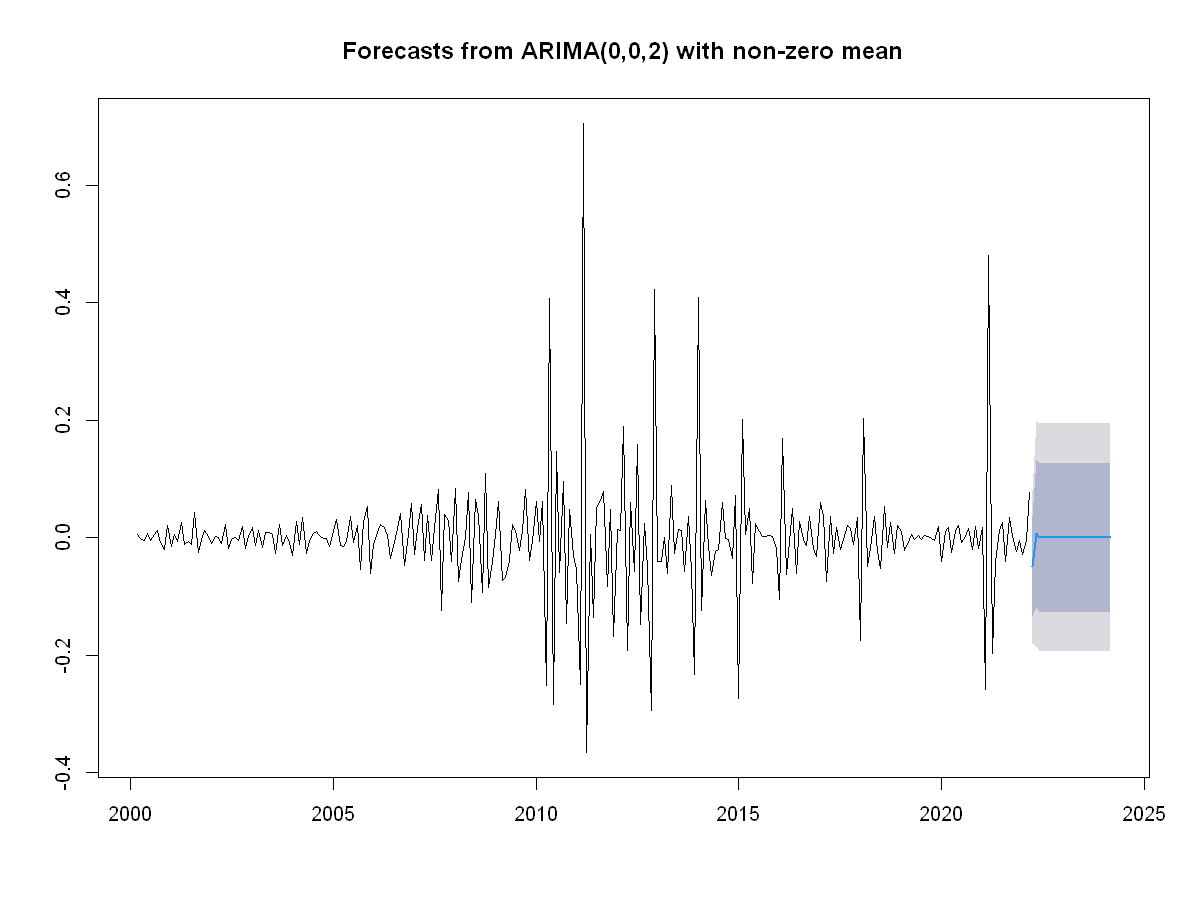

In [23]:
pred <- forecast(modelo)
par(bg = "white")
plot(pred)
grafico <- recordPlot()
png("..\\Gráficos\\Predicción.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)
accuracy(pred, test)

El modelo falla enormemente en predecir datos. Ahora aplicquemos la misma celda al modelo hecho con `auto.arima()`.

pdf 
  2

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.003514444,0.06659727,0.03746187,-0.0586896,1.513523,0.09423652,0.04673565,NA
Test set,0.069855083,0.07047575,0.06985508,3.7788506,3.778851,0.17572265,-0.08613905,6.320606


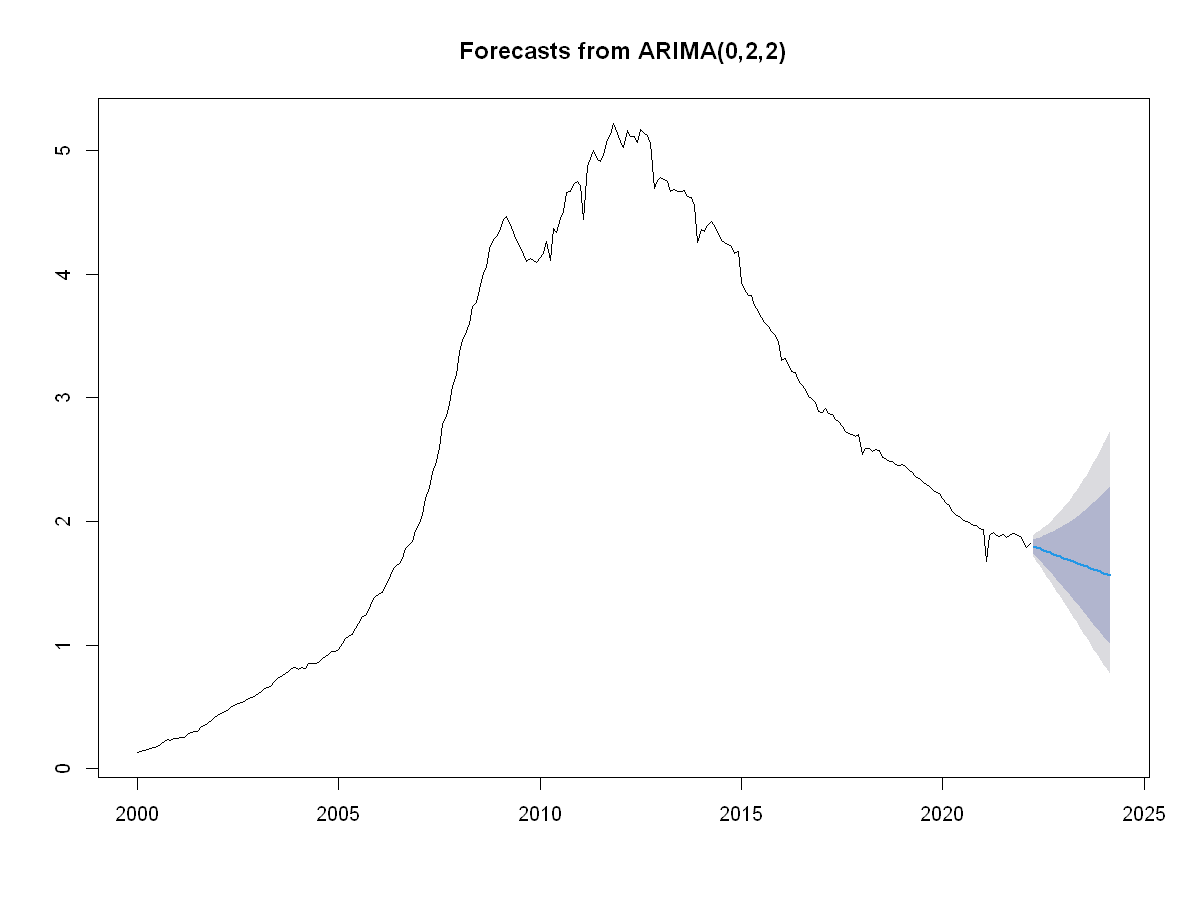

In [24]:
train <- window(gas, end = c(2022, 3))
modelo <- auto.arima(train, lambda = "auto")
pred <- forecast(modelo)
par(bg = "white")
plot(pred)
grafico <- recordPlot()
png("..\\Gráficos\\Predicción.png", width = 1000, height = 750)
replayPlot(grafico)
dev.off()
rm(grafico)
accuracy(pred, test)

El modelo es significativamente mejor para predecir datos. $\lambda$ es lo que arruina la **Metodología Box-Jenkins** <ins>manual</ins>, dado que su cálculo nunca se aprendió en ninguna asignatura, sin perjuicio de que un servidor sea capaz de dilucidar este asunto.

El análisis ha terminado y el modelo **ajusta apropiadamente**.